In [1]:
import numpy as np
import torch
import torch.nn as nn
import zipfile

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
torch.cuda.is_available()

False

In [4]:
import PIL.Image as Image
import torchvision.transforms.v2 as v2

trans = v2.Compose([
    v2.RandomRotation(degrees=15),
    v2.RandomAffine(degrees=0, translate=(0.01, 0.1))
])

In [5]:
# Load training data from subtask1/
def load_subtask1_data():
    with zipfile.ZipFile("train_data.zip", "r") as zf:
        train_data = {}
        for name in zf.namelist():
            if name.startswith("subtask1/") and name.endswith(".npy"):
                with zf.open(name) as f:
                    train_data[name] = np.load(f)
    
    # Concatenate all three scanners
    sub1_X = []
    sub1_y = []
    for s in [1, 2, 3]:
        x = train_data[f"subtask1/scanner{s}_X.npy"].astype(np.float32).reshape(500, 28, 28) / 255.0
        y = train_data[f"subtask1/scanner{s}_y.npy"].astype(np.int64)
        sub1_X.append(x)
        sub1_y.append(y)
        
        sub1_X.append(1.0 - x)
        sub1_y.append(y)

        
        if s == 1:
            x_new = []
            for x_ in x:
                x_new.append(np.array(trans(Image.fromarray(x_))))
            x_new = np.array(x_new)
            
            sub1_X.append(x_new)
            sub1_y.append(y)
            x_new = []
            for x_ in x:
                x_new.append(np.array(trans(Image.fromarray(x_))))
            x_new = np.array(x_new)
            
            sub1_X.append(1.0 - x_new)
            sub1_y.append(y)

        if s == 2:
            x_new = []
            for x_ in x:
                x_new.append(np.array(trans(Image.fromarray(1.0 - x_))))
            x_new = np.array(x_new)
            
            sub1_X.append(x_new)
            sub1_y.append(y)
            x_new = []
            for x_ in x:
                x_new.append(np.array(trans(Image.fromarray(1.0 - x_))))
            x_new = np.array(x_new)
            
            sub1_X.append(1.0 - x_new)
            sub1_y.append(y)

    X1 = np.concatenate(sub1_X, axis=0).reshape(-1, 1, 28, 28)
    y1 = np.concatenate(sub1_y, axis=0)
    print(X1.shape, y1.shape)
    return X1, y1

In [6]:
# Load training data from subtask2/
def load_subtask2_data():
    with zipfile.ZipFile("train_data.zip", "r") as zf:
        train_data = {}
        for name in zf.namelist():
            if name.startswith("subtask2/") and name.endswith(".npy"):
                with zf.open(name) as f:
                    train_data[name] = np.load(f)

    # Concatenate all eight scanners
    sub2_X = []
    sub2_y = []
    trans = v2.Compose([
        v2.RandomHorizontalFlip(),
        v2.RandomVerticalFlip()
    ])
    
    for s in range(1, 9):
        x = train_data[f"subtask2/scanner{s}_X.npy"].astype(np.float32).reshape(-1, 3, 28, 28) / 255.0
        y = train_data[f"subtask2/scanner{s}_y.npy"].astype(np.int64)
        
        sub2_X.append(x)
        sub2_y.append(y)
        
        # x_tensor = torch.from_numpy(x)
        # x_aug_tensor = trans(x_tensor)
        # x_aug = x_aug_tensor.numpy()
        
        # sub2_X.append(x_aug)
        # sub2_y.append(y)    
    X2 = np.concatenate(sub2_X, axis=0).reshape(-1, 3, 28, 28)
    y2 = np.concatenate(sub2_y, axis=0)
    print(X2.shape, y2.shape)
    return X2, y2

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 12, kernel_size=3, padding=1),
            nn.BatchNorm2d(12),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(12 * 7**2, num_classes)
        )
    def forward(self, x):
        # Handles both 1-ch (subtask1) and 3-ch (subtask2) input.
        # For subtask2, converts RGB to grayscale!
        if x.shape[1] == 3:
            x = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        
        col_top = x[:, :, 0, :]
        col_bottom = x[:, :, -1, :]

        col_mask = ((col_top >= 0.8) & (col_bottom >= 0.8))
        col_mask = col_mask.unsqueeze(2)
        
        x = torch.where(col_mask, 1.0 - x, x)
        
        row_left = x[:, :, :, 0]
        row_right = x[:, :, :, -1]
        row_mask = ((row_left >= 0.8) & (row_right >= 0.8))
        row_mask = row_mask.unsqueeze(3)
        
        x = torch.where(row_mask, 1.0 - x, x)        
        return self.net(x)

In [8]:
class SimpleCNN2(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 20, kernel_size=5, padding=2), 
            nn.BatchNorm2d(20),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 20, kernel_size=3, padding=1),
            nn.BatchNorm2d(20),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(20 * 7**2, num_classes)        
        )
    def forward(self, x):
        # Handles both 1-ch (subtask1) and 3-ch (subtask2) input.
        # For subtask2, converts RGB to grayscale!        
        return self.net(x)

In [9]:
def train_model(model, X, y, epochs=10, lr=0.005, batch_size=64):
    device = torch.device("cuda" if torch.cuda.is_available() else "mps")
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    val_size = 300
    X_val, y_val = torch.from_numpy(X[:val_size]).to(device), torch.from_numpy(y[:val_size]).long().to(device)
    X_train, y_train = torch.from_numpy(X[val_size:]).to(device), torch.from_numpy(y[val_size:]).long().to(device)

    num_train_samples = len(y_train)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(num_train_samples)
        total_loss = 0.0
        
        for start in range(0, num_train_samples, batch_size):
            idx = perm[start:start + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_train[idx]), y_train[idx])
            loss.backward()
            opt.step()
            total_loss += loss.item()

        # Clean validation evaluation
        model.eval()
        with torch.no_grad():
            acc = (model(X_val).argmax(1) == y_val).float().mean().item()
        print(f"  epoch {epoch:2d}: loss={total_loss:.4f}  val_acc={acc:.4f}")
    model.eval()
    return model.cpu()

In [10]:
X1, y1 = load_subtask1_data()

(5000, 1, 28, 28) (5000,)


In [11]:
X2, y2 = load_subtask2_data()

(4000, 3, 28, 28) (4000,)


In [12]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt

# def fix_background_numpy(img_np):
#     # Add batch and channel dimensions so it looks like (N=1, C=1, H=28, W=28)
#     img_out = img_np.copy()
#     H, W = img_out.shape
    
#     cols_to_flip = []
#     for c in range(W):
#         if img_out[0, c] >= 0.8 and img_out[-1, c] >= 0.8:
#             img_out[:, c] = 1.0 - img_out[:, c]        
#     for r in range(H):
#         if img_out[r, 0]>= 0.8 and img_out[r, -1] >= 0.8:
#             img_out[r, :] = 1.0 - img_out[r, :]
#     return img_out
# idx = 3640

# plt.matshow(X1[idx][0])
# plt.matshow(fix_background_numpy(X1[idx][0]))

In [13]:
perm1 = np.random.permutation(len(X1))
perm2 = np.random.permutation(len(X2))

X1 = X1[perm1]
y1 = y1[perm1]

X2 = X2[perm2]
y2 = y2[perm2]

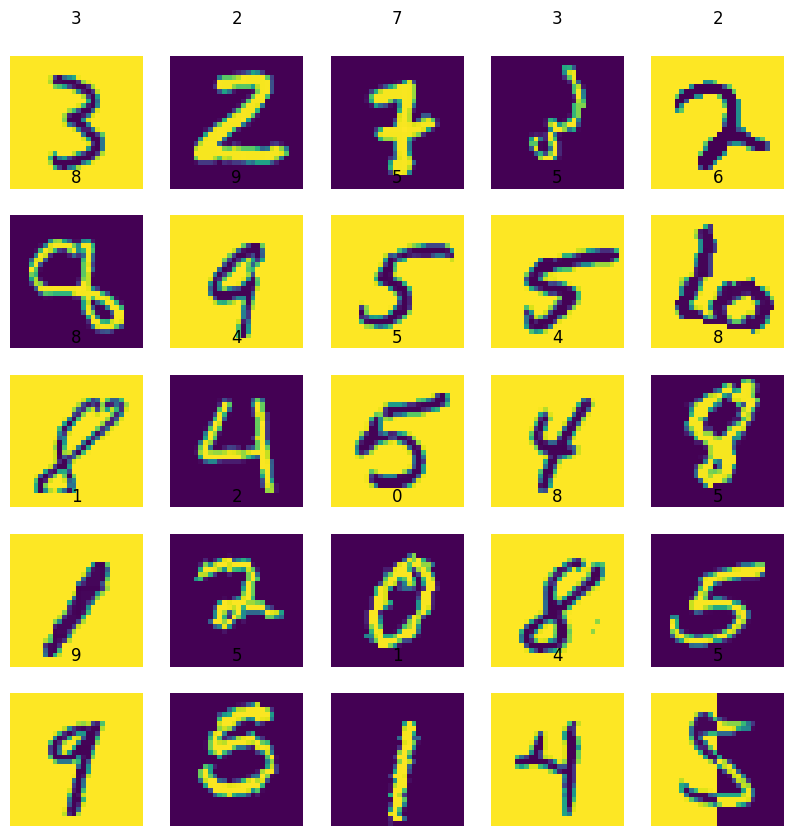

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(5, 5)
fig.set_figwidth(10)
fig.set_figheight(10)

for i in range(25):
    ax[i // 5][i % 5].matshow(X1[i][0])
    ax[i // 5][i % 5].set_title(y1[i])
    ax[i // 5][i % 5].axis("off")

In [15]:
# Train Subtask 1 starter model
model1 = SimpleCNN()
params1 = sum(p.numel() for p in model1.parameters())
print(f"  params: {params1:,}")
model1 = train_model(model1, X1, y1, epochs=100)

  params: 10,278
  epoch  0: loss=41.9963  val_acc=0.9467
  epoch  1: loss=10.6182  val_acc=0.9800
  epoch  2: loss=4.9488  val_acc=0.9833
  epoch  3: loss=2.7042  val_acc=0.9800
  epoch  4: loss=1.4669  val_acc=0.9733
  epoch  5: loss=0.9476  val_acc=0.9767
  epoch  6: loss=0.4235  val_acc=0.9767
  epoch  7: loss=0.3823  val_acc=0.9867
  epoch  8: loss=0.3625  val_acc=0.9867
  epoch  9: loss=0.2331  val_acc=0.9767
  epoch 10: loss=0.0991  val_acc=0.9867
  epoch 11: loss=0.0574  val_acc=0.9867
  epoch 12: loss=0.0383  val_acc=0.9867
  epoch 13: loss=0.0335  val_acc=0.9867
  epoch 14: loss=0.0266  val_acc=0.9867
  epoch 15: loss=0.0240  val_acc=0.9867
  epoch 16: loss=0.0227  val_acc=0.9867
  epoch 17: loss=0.0198  val_acc=0.9867
  epoch 18: loss=0.0187  val_acc=0.9867
  epoch 19: loss=0.0165  val_acc=0.9867
  epoch 20: loss=0.0150  val_acc=0.9867
  epoch 21: loss=0.0143  val_acc=0.9867
  epoch 22: loss=0.0133  val_acc=0.9867
  epoch 23: loss=0.0118  val_acc=0.9867
  epoch 24: loss=0.01

KeyboardInterrupt: 

In [16]:
# Export Subtask 1 model with jit.script
model1.eval();
script1 = torch.jit.script(model1)
torch.jit.save(script1, "model_sub1.pt")
print(f"Exported model_sub1.pt")

Exported model_sub1.pt


In [17]:
# Train Subtask 2 starter model
model2 = SimpleCNN2()
params2 = sum(p.numel() for p in model2.parameters())
print(f"  params: {params2:,}")
model2 = train_model(model2, X2, y2, epochs=200, lr=0.001)

  params: 23,046
  epoch  0: loss=103.5438  val_acc=0.5367
  epoch  1: loss=67.0817  val_acc=0.5933
  epoch  2: loss=57.1923  val_acc=0.6333
  epoch  3: loss=49.5615  val_acc=0.6633
  epoch  4: loss=42.3537  val_acc=0.7367
  epoch  5: loss=36.0714  val_acc=0.7233
  epoch  6: loss=30.1017  val_acc=0.7300
  epoch  7: loss=25.3909  val_acc=0.7600
  epoch  8: loss=21.1040  val_acc=0.7700
  epoch  9: loss=19.0575  val_acc=0.7667
  epoch 10: loss=16.3137  val_acc=0.7867
  epoch 11: loss=14.1731  val_acc=0.8067
  epoch 12: loss=11.8225  val_acc=0.8067
  epoch 13: loss=10.7094  val_acc=0.7867
  epoch 14: loss=9.3028  val_acc=0.8033
  epoch 15: loss=7.9303  val_acc=0.8033
  epoch 16: loss=7.4324  val_acc=0.7767
  epoch 17: loss=5.8246  val_acc=0.8133
  epoch 18: loss=5.8400  val_acc=0.8333
  epoch 19: loss=5.2514  val_acc=0.7667
  epoch 20: loss=4.3501  val_acc=0.8300
  epoch 21: loss=3.6586  val_acc=0.7800
  epoch 22: loss=3.3525  val_acc=0.8300
  epoch 23: loss=2.7079  val_acc=0.8400
  epoch 

In [18]:
# Export Subtask 2 model with jit.script
model2.eval();
script2 = torch.jit.script(model2)
torch.jit.save(script2, "model_sub2.pt")
print(f"Exported model_sub2.pt")

Exported model_sub2.pt


In [19]:
# Make zip submission
with zipfile.ZipFile("submission2.zip", "w") as zf:
    zf.write("model_sub1.pt")
    zf.write("model_sub2.pt")
print("Wrote submission2.zip!")

Wrote submission2.zip!
